## **What is Data Transformation?**

**Data transformation** is the process of **modifying data** into a format that is more suitable for analysis or modeling. It involves applying **mathematical functions or rules** to variables to:

* Improve model accuracy
* Handle skewness
* Make relationships more linear
* Normalize distributions
* Reduce the effect of outliers

## **Types of Data Transformation**

### 1. **Scaling Transformation**

Changes the **scale** of the data.

* **Standardization (Z-score):**

  $$
  X' = \frac{X - \mu}{\sigma}
  $$

  Mean = 0, Std Dev = 1

* **Min-Max Scaling:**

  $$
  X' = \frac{X - \text{min}}{\text{max} - \text{min}}
  $$

  Rescales data to \[0, 1]

* **MaxAbs Scaling:**

  $$
  X' = \frac{X}{\text{max}(|X|)}
  $$

  Keeps sign, good for sparse data

### 2. **Nonlinear Transformation**

Used to **reduce skewness** or **normalize** the distribution.

####  **Log Transformation**

* Reduces right-skewness
  $$
  X' = \log(X)
  $$

####  **Square Root Transformation**

* Less aggressive than log
 $$
  X' = \sqrt{X}
  $$

####  **Reciprocal Transformation**

 $$
  X' = \frac{1}{X}
  $$

### 3. **Power Transformation**

Used to **stabilize variance** and **make data more normal**.

#### **Box-Cox Transformation**

* Only for **positive** data
 $$
  X' = \text{BoxCox}(X, \lambda)
  $$

####  **Yeo-Johnson Transformation**

* Works for **zero or negative** values
* More flexible than Box-Cox


## Summary Table

| Transformation     | Use When                  | Handles Negative? | Goal                             |
| ------------------ | ------------------------- | ----------------- | -------------------------------- |
| Log                | Right-skewed data         | No              | Normalize, compress large values |
| Square Root        | Mildly skewed data        | No              | Reduce skewness                  |
| Reciprocal         | Very skewed data          | No              | Reduce impact of large values    |
| Box-Cox            | Non-normal, positive data | No              | Make normal-like                 |
| Yeo-Johnson        | Non-normal data           | Yes             | Make normal-like                 |
| Quantile Transform | Irregular distributions   | Yes             | Map to normal/uniform            |



## 1. Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

These are standard libraries used for:
- pandas: data manipulation
- seaborn/matplotlib: data visualization
- numpy: numerical computations

## 2. Reading and Previewing the Dataset

In [2]:
dataset = pd.read_csv("loan.csv")
dataset.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


- Reads a dataset named loan.csv.
- Displays the first 10 rows for an overview.

## 3. Checking for Missing Values

In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 4. Visualizing CoapplicantIncome Distribution

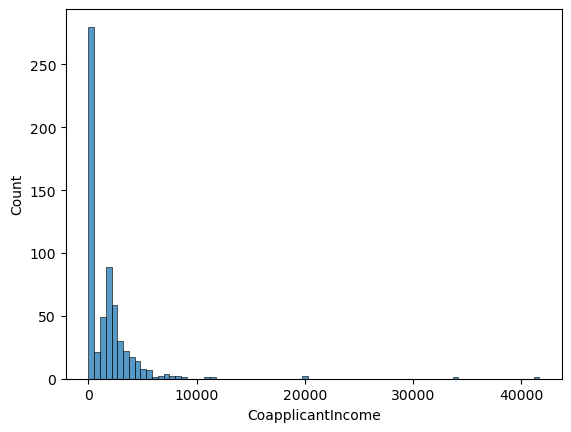

In [4]:
sns.histplot(dataset['CoapplicantIncome'])
plt.show()

- Shows the distribution of co-applicant income.
- Note: distplot is deprecated, warnings are shown. Use histplot or displot instead.

## 5. Removing Outliers from CoapplicantIncome

In [5]:
q1 = dataset['CoapplicantIncome'].quantile(0.25)
q3 = dataset['CoapplicantIncome'].quantile(0.75)
iqr = q3-q1

In [6]:
min_r = q1-(1.5 * iqr)
max_r = q3+(1.5 * iqr)

min_r ,max_r

(np.float64(-3445.875), np.float64(5743.125))

In [7]:
dataset = dataset[dataset['CoapplicantIncome'] <= max_r]

- Calculates IQR (Interquartile Range) to define outlier thresholds.
- Removes values above the upper limit (max_r) — right-side outliers only.

## 6. Visualizing Again After Outlier Removal

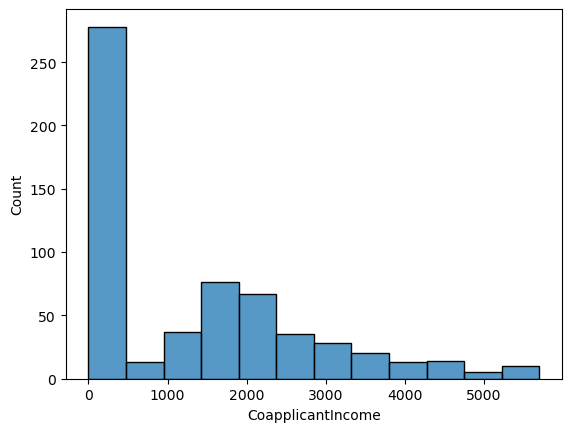

In [8]:
sns.histplot(dataset['CoapplicantIncome'])
plt.show()

- Compares the distribution after outliers are removed.

## 7. Applying Log Transformation

In [9]:
from sklearn.preprocessing import FunctionTransformer

In [10]:
ft = FunctionTransformer(func = np.log1p)

In [11]:
dataset["CoapplicantIncome_tf"] = ft.fit_transform(dataset['CoapplicantIncome'])

- Applies log transformation using np.log1p(x) (which computes log(1 + x)) to handle skewness.
- Creates a new column: CoapplicantIncome_tf.

## 8. Plotting Before vs After Log Transform

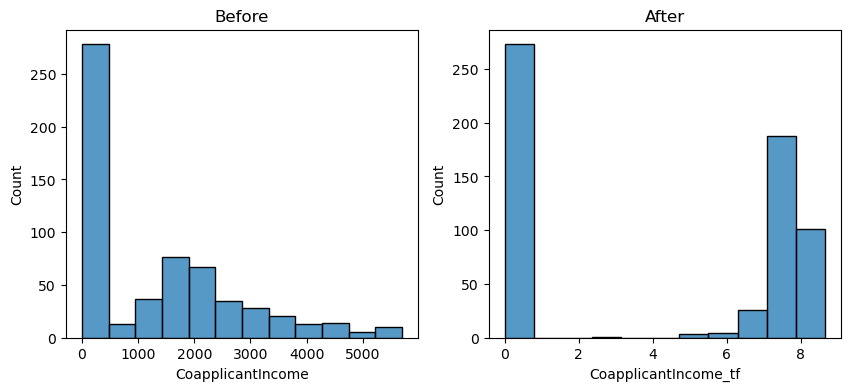

In [12]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.histplot(dataset['CoapplicantIncome'])
plt.title('Before')

plt.subplot(1,2,2)
sns.histplot(dataset['CoapplicantIncome_tf'])
plt.title('After')
plt.show()

- Compares the original and log-transformed data distributions.

## 9. Applying a Custom Transformation (Square)

In [13]:
ft1 = FunctionTransformer(func = lambda x : x**2)
dataset["CoapplicantIncome_tf1"] = ft1.fit_transform(dataset['CoapplicantIncome'])

- Applies a square transform (x²) to the original income.
- Stores result in CoapplicantIncome_tf1.

## 10. Plotting Before vs After Square Transform

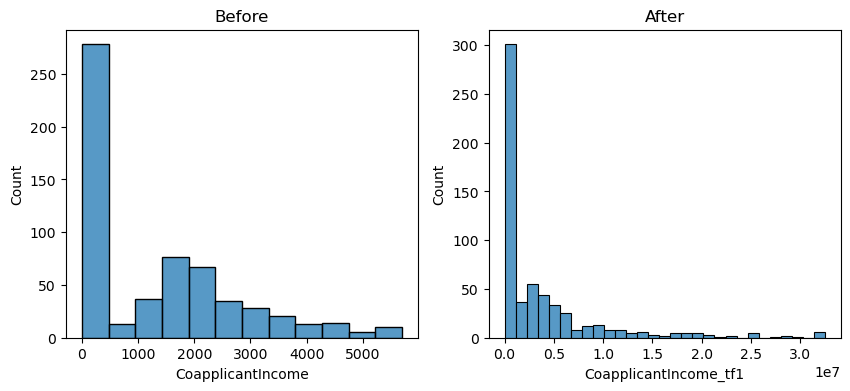

In [14]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.histplot(dataset['CoapplicantIncome'])
plt.title('Before')

plt.subplot(1,2,2)
sns.histplot(dataset['CoapplicantIncome_tf1'])
plt.title('After')
plt.show()

- Shows the effect of squaring the data.
- Normally used to amplify differences.

### Deprecation Warning
Throughout the code, there's a recurring warning:
- distplot is deprecated.

### You should use:

- sns.histplot() for similar effect.
- or sns.displot() for more flexibility.

### Summary
The code demonstrates:

- Data cleaning (missing values, outliers)
- Data transformation using FunctionTransformer
- Visual comparison of original vs transformed data
- Use of different transformation techniques (log1p, x²)

In [15]:
# Set random seed for reproducibility
np.random.seed(42)

In [16]:
# Generate exponential data (highly right-skewed)
data = np.random.exponential(scale=2.0, size=1000)

In [17]:
# Convert to DataFrame
df = pd.DataFrame(data, columns = ["feature"])
df

,feature
0,0.938536
1,6.020243
2,2.633491
3,1.825885
4,0.339250
...,...
995,0.192101
996,4.985400
997,0.294261
998,6.000981


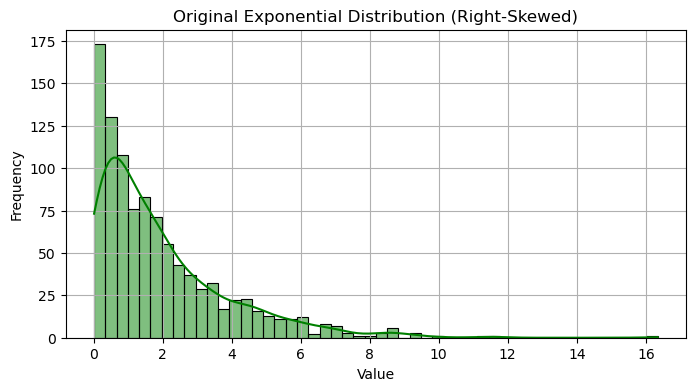

In [18]:
# Plot histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['feature'], bins=50, kde=True, color='green')
plt.title('Original Exponential Distribution (Right-Skewed)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [19]:
from sklearn.preprocessing import QuantileTransformer, PowerTransformer

In [20]:
# Apply PowerTransformer with Yeo-Johnson (default)
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df['yeo_transformed'] = pt.fit_transform(df[['feature']])

In [21]:
# Optional: Try Box-Cox (only works if all values > 0)
pt_bc = PowerTransformer(method='box-cox')
df['boxcox_transformed'] = pt_bc.fit_transform(df[['feature']]) 

In [22]:
# Quantile Transformer to normal distribution
qt = QuantileTransformer(output_distribution='normal')
df['qt_transformed'] = qt.fit_transform(df[['feature']])

In [23]:
# Apply log transformation
df['Log_Transformed'] = np.log1p(df['feature'])  # log(1 + x) for safety

In [24]:
# Apply square root transformation
df['Sqrt_Transformed'] = np.sqrt(df['feature'])

In [25]:
df.head()

,feature,yeo_transformed,boxcox_transformed,qt_transformed,Log_Transformed,Sqrt_Transformed
0,0.938536,-0.342865,-0.273777,-0.273089,0.661933,0.968781
1,6.020243,1.644439,1.640981,1.738731,1.948798,2.453618
2,2.633491,0.746073,0.680543,0.645631,1.290194,1.622804
3,1.825885,0.340704,0.313725,0.286135,1.038822,1.351253
4,0.339250,-1.113723,-1.005096,-0.933910,0.292110,0.582451


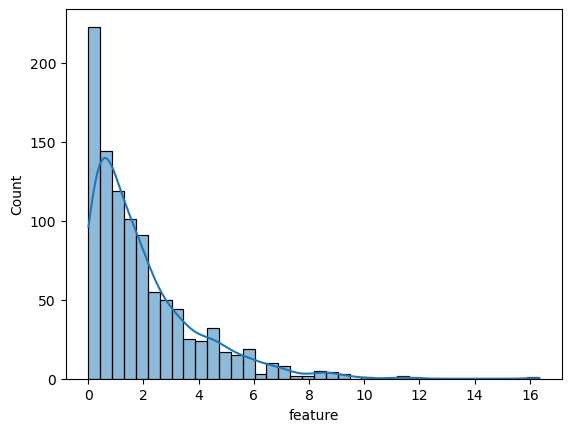

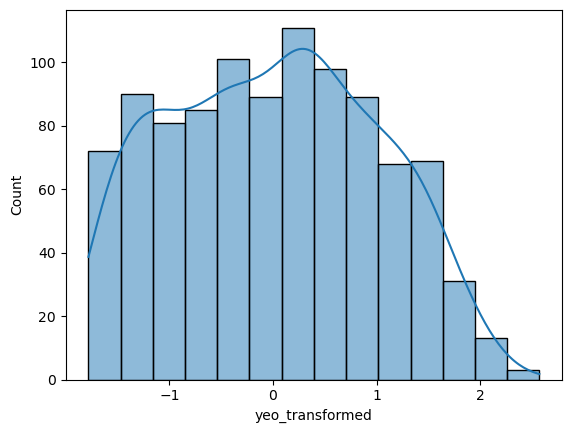

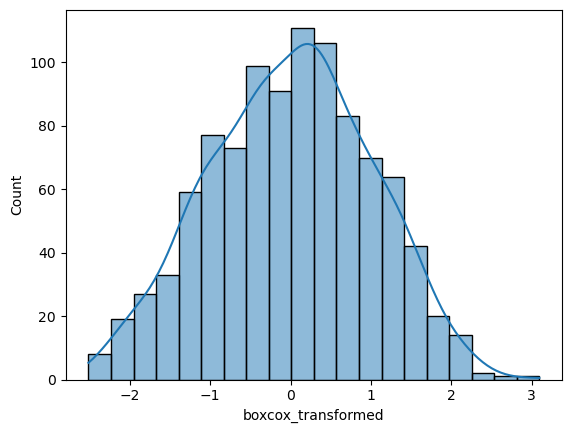

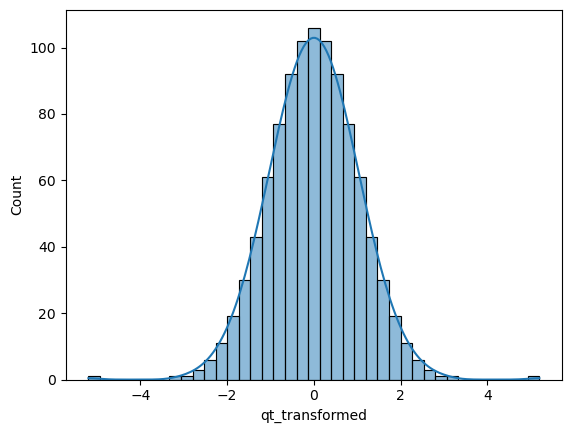

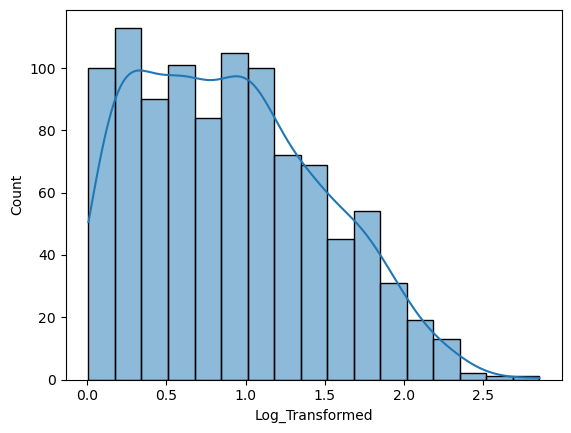

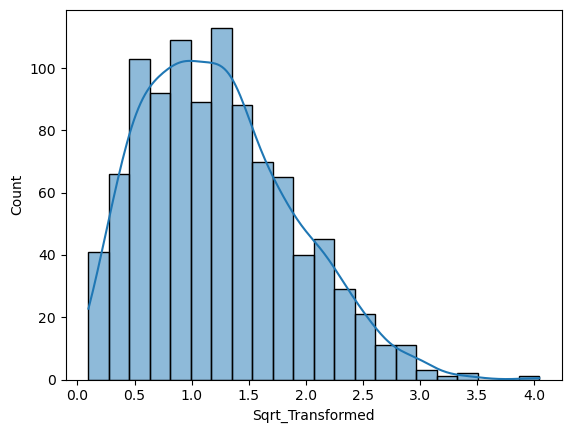

In [26]:
# creata hostograms for all columns using sns.hist and kde=true use a for loop
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()

## **Quick Tips:**

* Use **log**, **sqrt**, or **reciprocal** for **skewed data**.
* Use **Box-Cox** or **Yeo-Johnson** for **normality**.
* Use **Z-score** or **MinMaxScaler** for **scaling features** before modeling.
* Use **QuantileTransformer** to force data into **uniform/normal distribution**.
* Use **RobustScaler** if your data has **outliers**.
